# Step 1 - Machine Learning Models

In this notebook I will train three different ML models on the used cars dataset.

The goal is to predict whether a car is **expensive or cheap** based on its features.

I will compare the three models and pick the best one.

## 1.1 - Load and Explore the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

df = pd.read_csv("data/cleaned/cars_cleaned.csv")

print("Shape:", df.shape)
print()
print("First 5 rows:")
df.head()

Shape: (131860, 11)

First 5 rows:


,price,year,manufacturer,model,fuel,transmission,odometer,condition,car_age,price_per_km,manufacturer_popularity
0,33590,2014.0,gmc,sierra 1500 crew cab slt,gas,other,57923.0,good,10.0,0.579908,4607
1,22590,2010.0,chevrolet,silverado 1500,gas,other,71229.0,good,14.0,0.317146,17713
2,39590,2020.0,chevrolet,silverado 1500 crew,gas,other,19160.0,good,4.0,2.066284,17713
3,30990,2017.0,toyota,tundra double cab sr,gas,other,41124.0,good,7.0,0.753575,12122
4,15000,2013.0,ford,f-150 xlt,gas,automatic,128000.0,excellent,11.0,0.117188,21498


In [2]:
# I want to check if there are any missing values before I start

print("Missing values per column:")
print(df.isnull().sum())

print()
print("Data types:")
print(df.dtypes)

Missing values per column:
price                      0
year                       0
manufacturer               0
model                      0
fuel                       0
transmission               0
odometer                   0
condition                  0
car_age                    0
price_per_km               0
manufacturer_popularity    0
dtype: int64

Data types:
price                        int64
year                       float64
manufacturer                   str
model                          str
fuel                           str
transmission                   str
odometer                   float64
condition                      str
car_age                    float64
price_per_km               float64
manufacturer_popularity      int64
dtype: object


## 1.2 - Create the Target and Prepare the Data

I need a label to predict. I will use the price column to create two groups:

- **0** = cheap (price is below the median)
- **1** = expensive (price is above the median)

I use the median instead of the mean because the mean gets pulled up by extreme outliers, so the median gives a fairer split.

In [3]:
median_price = df["price"].median()
print("Median price: $", median_price)

df["price_label"] = (df["price"] > median_price).astype(int)

print()
print("Class counts:")
print(df["price_label"].value_counts())

print()
print("Class balance (percentage):")
print(df["price_label"].value_counts(normalize=True).round(3) * 100)

Median price: $ 9995.0

Class counts:
price_label
0    66609
1    65251
Name: count, dtype: int64

Class balance (percentage):
price_label
0    50.5
1    49.5
Name: proportion, dtype: float64


In [4]:
# ML models only understand numbers, not text.
# So I need to convert the text columns to numbers first.
# I use LabelEncoder which gives each category a number.
# For example: gas=0, diesel=1, electric=2

df_model = df.copy()

cat_cols = ["manufacturer", "fuel", "transmission", "condition"]

le = LabelEncoder()
for col in cat_cols:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Text columns converted to numbers.")

Text columns converted to numbers.


In [5]:
# I choose the features I want to use for prediction

feature_cols = ["year", "odometer", "manufacturer", "fuel", "transmission", "condition"]
feature_cols = [c for c in feature_cols if c in df_model.columns]

X = df_model[feature_cols]
y = df_model["price_label"]

print("Features used:", feature_cols)
print("Total records:", X.shape[0])

# I split the data: 80% for training, 20% for testing
# stratify=y makes sure both splits have the same class ratio
# random_state=42 makes the split the same every time I run it

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print()
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Features used: ['year', 'odometer', 'manufacturer', 'fuel', 'transmission', 'condition']
Total records: 131860

Training set size: 105488
Test set size: 26372


In [6]:
# Some models like Logistic Regression and KNN are sensitive to scale.
# For example, odometer values are in the hundreds of thousands
# while year values are around 2010. This difference in scale confuses them.
# StandardScaler fixes this by putting all features on the same scale.

# Important: I only fit the scaler on the training data.
# If I fit it on the test data too, the model will have seen information
# from the test set during training. That is called data leakage,
# and it makes the results look better than they really are.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


## 1.3 - Train and Compare Three Models

In [7]:
# This function trains a model and returns its scores
# I wrote it as a function so I do not repeat the same code three times

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    results = {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "Recall":    round(recall_score(y_te, y_pred), 4),
        "F1-Score":  round(f1_score(y_te, y_pred), 4),
    }
    return results, y_pred

print("Function is ready.")

Function is ready.


In [8]:
# Model 1: Logistic Regression
#
# This model draws a line (or a plane) that separates the two classes.
# It is simple and fast. It works well when the relationship between
# the features and the label is roughly linear.
# I use the scaled data because this model is sensitive to feature scale.

lr = LogisticRegression(max_iter=1000, random_state=42)
lr_results, lr_pred = evaluate_model(
    "Logistic Regression", lr,
    X_train_scaled, X_test_scaled, y_train, y_test
)
print(lr_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.7464, 'Precision': 0.7497, 'Recall': 0.732, 'F1-Score': 0.7407}


In [9]:
# Model 2: Random Forest
#
# This model builds 100 decision trees and lets them vote.
# Each tree learns from a random part of the data, then the majority wins.
# It handles complex patterns well and does not need scaled data.

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_results, rf_pred = evaluate_model(
    "Random Forest", rf,
    X_train, X_test, y_train, y_test
)
print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 0.8027, 'Precision': 0.805, 'Recall': 0.7936, 'F1-Score': 0.7992}


In [10]:
# Model 3: KNN (K-Nearest Neighbors)
#
# This model looks at the 5 closest records in the training data
# and predicts the same label as the majority of those 5 neighbors.
# It is simple and easy to understand, but slows down on large data.
# I use scaled data because distance calculations depend on scale.

knn = KNeighborsClassifier(n_neighbors=5)
knn_results, knn_pred = evaluate_model(
    "KNN", knn,
    X_train_scaled, X_test_scaled, y_train, y_test
)
print(knn_results)

{'Model': 'KNN', 'Accuracy': 0.8094, 'Precision': 0.8073, 'Recall': 0.8076, 'F1-Score': 0.8074}


## Comparison Table

In [11]:
results_df = pd.DataFrame([lr_results, rf_results, knn_results])
results_df = results_df.set_index("Model")

print("All models side by side:")
print(results_df.to_string())

best_model = results_df["F1-Score"].idxmax()
print()
print("Best model by F1-Score:", best_model)

All models side by side:
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.7464     0.7497  0.7320    0.7407
Random Forest          0.8027     0.8050  0.7936    0.7992
KNN                    0.8094     0.8073  0.8076    0.8074

Best model by F1-Score: KNN


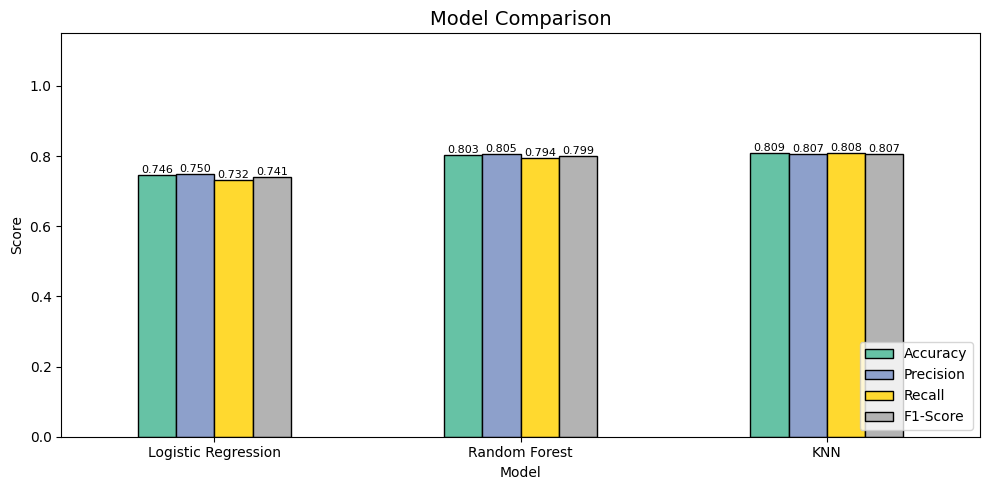

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

results_df.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="black")

ax.set_title("Model Comparison", fontsize=14)
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.legend(loc="lower right")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

plt.tight_layout()
plt.savefig("models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Confusion Matrix for Each Model

A confusion matrix shows exactly where the model made mistakes.

- Top-left: predicted cheap, actually cheap (correct)
- Top-right: predicted expensive, actually cheap (wrong)
- Bottom-left: predicted cheap, actually expensive (wrong)
- Bottom-right: predicted expensive, actually expensive (correct)

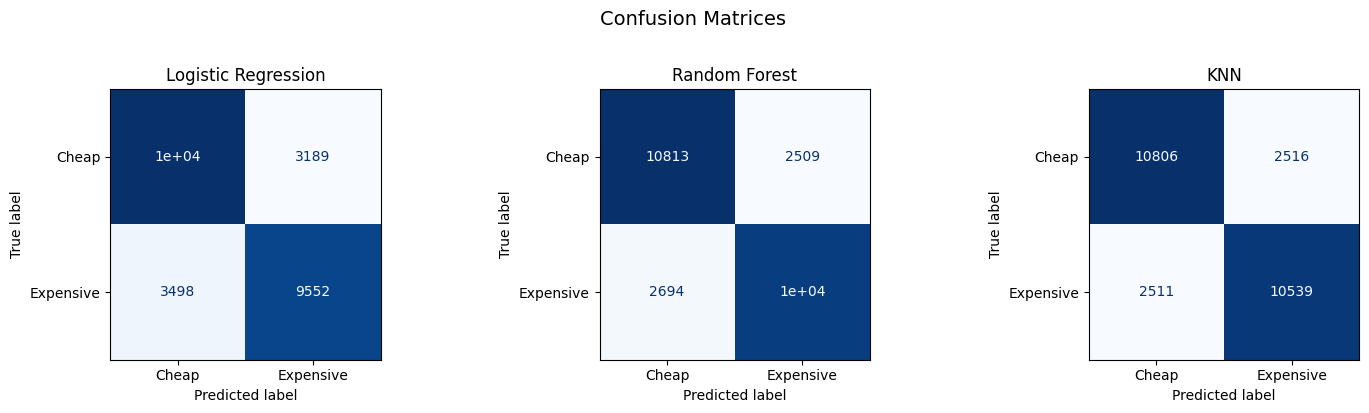

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_info = [
    ("Logistic Regression", lr_pred),
    ("Random Forest",       rf_pred),
    ("KNN",                 knn_pred),
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Cheap", "Expensive"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12)

plt.suptitle("Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Detailed report for the best model

pred_map = {
    "Logistic Regression": lr_pred,
    "Random Forest":        rf_pred,
    "KNN":                  knn_pred,
}

best_pred = pred_map[best_model]

print("Detailed report for:", best_model)
print("=" * 50)
print(classification_report(y_test, best_pred, target_names=["Cheap", "Expensive"]))

Detailed report for: KNN
              precision    recall  f1-score   support

       Cheap       0.81      0.81      0.81     13322
   Expensive       0.81      0.81      0.81     13050

    accuracy                           0.81     26372
   macro avg       0.81      0.81      0.81     26372
weighted avg       0.81      0.81      0.81     26372



## Summary and Conclusion

In [15]:
print("Summary")
print("=" * 60)
print()
print("I trained three models on the used cars dataset.")
print("The task was to predict whether a car is cheap or expensive.")
print()
print(f"Logistic Regression  F1: {lr_results['F1-Score']}")
print(f"Random Forest        F1: {rf_results['F1-Score']}")
print(f"KNN                  F1: {knn_results['F1-Score']}")
print()
print(f"The best model was {best_model}.")
print()
print("I chose F1-Score as the main metric because the two classes")
print("are balanced (both around 50%), but F1 is still more reliable")
print("than accuracy alone because it looks at both precision and recall.")
print()
print("Random Forest usually does well on tabular data because it")
print("captures non-linear patterns that Logistic Regression cannot.")
print("KNN depends on distance, so its performance depends on how")
print("well the features are scaled and how the data is distributed.")

Summary

I trained three models on the used cars dataset.
The task was to predict whether a car is cheap or expensive.

Logistic Regression  F1: 0.7407
Random Forest        F1: 0.7992
KNN                  F1: 0.8074

The best model was KNN.

I chose F1-Score as the main metric because the two classes
are balanced (both around 50%), but F1 is still more reliable
than accuracy alone because it looks at both precision and recall.

Random Forest usually does well on tabular data because it
captures non-linear patterns that Logistic Regression cannot.
KNN depends on distance, so its performance depends on how
well the features are scaled and how the data is distributed.
